In [1]:
#Import Libraries :

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt 
import seaborn as sns  

C:\Users\A. shakti sivaraman\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\A. shakti sivaraman\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
# Loading of  dataset:

df = pd.read_csv("hospitaldata.csv")

In [3]:
#Displaying the Shape of the imported Data Set:

print("Shape of the DataFrame:", df.shape)

Shape of the DataFrame: (101763, 47)


In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,examide,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),Unknown,_Other,Referral,1,Other,...,No,No,No,No,No,No,No,No,No,No
1,149190,55629189,Caucasian,Female,[10-20),Unknown,Home,Emergency,3,Other,...,No,No,Up,No,No,No,No,Yes,Yes,After30Days
2,64410,86047875,AfricanAmerican,Female,[20-30),Unknown,Home,Emergency,2,Other,...,No,No,No,No,No,No,No,No,Yes,No
3,500364,82442376,Caucasian,Male,[30-40),Unknown,Home,Emergency,2,Other,...,No,No,Up,No,No,No,No,Yes,Yes,No
4,16680,42519267,Caucasian,Male,[40-50),Unknown,Home,Emergency,1,Other,...,No,No,Steady,No,No,No,No,Yes,Yes,No


In [5]:
#check whether  the target value exist:

if 'readmitted' not in df.columns:
    raise ValueError("The dataset does not contain the 'readmitted' column!")

In [6]:
# Converntion of target variable into binary format (integer):

df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == "Within30Days" else 0).astype(int)

In [7]:
# Identifying all categorical columns in the dataset dynamically:

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [8]:
# Finding numerical columns dynamically:

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [9]:
# Applying StandardScaler for numerical features:

scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [10]:
# verify whether dataset is fully numeric:

non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()
if len(non_numeric_columns) > 0:
    print(" Non-numeric columns detected:", non_numeric_columns)
    raise ValueError("Dataset still contains non-numeric values!")

In [11]:
# Defining features (A1) and target variable (B2):

A1 = df.drop(columns=['readmitted'])
B2= df['readmitted'].astype(int) 

In [12]:
# Spliting the dataset into training (80%) and testing (20%):

V_train, V_test, W_train, W_test = train_test_split(A1, B2, test_size=0.2, random_state=42, stratify=B2)

In [13]:
# Training logistic regression model:

model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(V_train, W_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [14]:
# Making predictions according to it:

W_pred = model.predict(V_test)

In [15]:
# Analysing model:

accuracy = accuracy_score(W_test, W_pred)
conf_matrix = confusion_matrix(W_test, W_pred)
roc_auc = roc_auc_score(W_test, model.predict_proba(V_test)[:, 1])

In [16]:
# Final Results for Displaying:

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("ROC-AUC Score:", roc_auc)
print("Classification Performance :\n", classification_report(W_test, W_pred))

Accuracy: 0.8882228664079006
Confusion Matrix:
 [[18042    40]
 [ 2235    36]]
ROC-AUC Score: 0.6487810727304173
Classification Performance :
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.47      0.02      0.03      2271

    accuracy                           0.89     20353
   macro avg       0.68      0.51      0.49     20353
weighted avg       0.84      0.89      0.84     20353



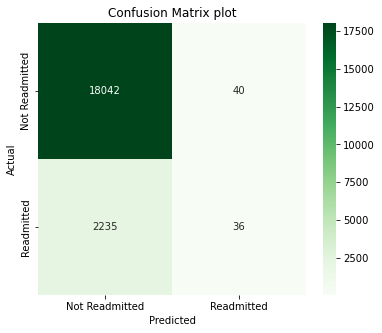

In [17]:
# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Readmitted', 'Readmitted'], yticklabels=['Not Readmitted', 'Readmitted'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix plot")
plt.show()